### ReAct Agent
The ReAct Pattern (short for Reason + Act) is a design pattern in agentic AI where an agent alternates between thinking (reasoning) and taking actions (tool use) to solve a problem step by step.

Thought → Action → Observation → Thought → … → Final Answer

In [1]:
from langgraph.graph import MessagesState,StateGraph, END, START
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import tools_condition # this is the checker for the if you got a tool back
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from typing import Annotated, TypedDict
import operator
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
import os
from langchain_groq import ChatGroq

/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm=ChatGroq(model="llama-3.1-8b-instant")

In [3]:
@tool
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.
    Args:
        a: first int
        b: second int
    """
    return a * b

In [4]:
@tool
def add(a: float, b: float) -> float:
    """Adds a and b.

    Args:
        a: first float
        b: second float
    """
    return a + b

In [5]:
@tool
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [6]:
search = DuckDuckGoSearchRun()

In [7]:
search.invoke("who is a current president of USA?")

'... presidents are typically viewed as leaders of their political parties, major policymaking is significantly shaped by the outcome of presidential ... baɪdən/ BY-dən; born November 20, 1942) is an American politician serving as the 46th and current president of the United States. Donald Trump is the 47th and current president of the United States, in office since January 20, 2025. ... president-elect of the United States is the ... The question, “Who is the President of the USA?”, has always been more than a matter of fact—it reflects the direction, mood, and priorities of ... ... a presidential election, the president is selected by electors within the Electoral College to serve a four-year term, with the candidate who secures ...'

In [8]:
tools=[add,multiply,divide,search]

In [9]:
llm_with_tools=llm.bind_tools(tools)

In [10]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.")
     

In [11]:
## reasoner node which will think and act

def reasoner(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg]+state["messages"])]}

In [12]:
# Graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("reasoner", reasoner)

builder.add_node("tools", ToolNode(tools)) # for the tools

# Add edges
builder.add_edge(START, "reasoner")

builder.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

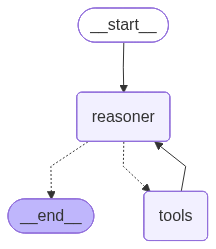

In [13]:
# Display the graph
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [14]:
messages = [HumanMessage(content="What is 2 times of narendramodi's age?")]

In [15]:
messages = react_graph.invoke({"messages": messages})

In [16]:
messages

{'messages': [HumanMessage(content="What is 2 times of narendramodi's age?", additional_kwargs={}, response_metadata={}, id='aac07464-f4b4-4421-901f-7588f6769433'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7rea7f9fr', 'function': {'arguments': '{"query":"narendramodi age in 2024"}', 'name': 'duckduckgo_search'}, 'type': 'function'}, {'id': 'hqwynmjaa', 'function': {'arguments': '{"a":2,"b":69}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 554, 'total_tokens': 597, 'completion_time': 0.066572807, 'completion_tokens_details': None, 'prompt_time': 0.031326053, 'prompt_tokens_details': None, 'queue_time': 0.052610287, 'total_time': 0.09789886}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019decb1-cbd9-7cb3-a146-fd0d9b74b4cf-0', tool_calls=[{'

In [17]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 times of narendramodi's age?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (7rea7f9fr)
 Call ID: 7rea7f9fr
  Args:
    query: narendramodi age in 2024
  multiply (hqwynmjaa)
 Call ID: hqwynmjaa
  Args:
    a: 2
    b: 69
================================= Tool Message =================================
Name: duckduckgo_search

Modi was born and raised in Vadnagar, Bombay State (present-day Gujarat), where he completed his secondary education. He was introduced to the RSS at the age of eight, becoming a full-time worker for the organisation in Gujarat in 1971. Witness the incredible age transformation of Indian Prime Minister Narendra Modi from 1950 to 2024 in this compelling video.Countries legally marriage Age in 2025 different countries marriage Age Asian countries boys and girls marriage Age #pro_data_list #foryou #prodatalist. 

In [18]:
## another example of ReAct agent

In [19]:
import yfinance as yf

@tool
def get_stock_price(ticker: str) -> float:
    """Gets a stock price from Yahoo Finance.

    Args:
        ticker: ticker str
    """
    # """This is a tool for getting the price of a stock when passed a ticker symbol"""
    stock = yf.Ticker(ticker)
    return stock.info['previousClose']

In [20]:
class GraphState(TypedDict):
    query:str
    finance:str
    final_answer:str
    messages: Annotated[list[AnyMessage], operator.add]

In [21]:
tools=[add,multiply,divide,search,get_stock_price]

llm_with_tools=llm.bind_tools(tools)

In [22]:
# reasoner node

def reasoner(state:GraphState):
    query=state["query"]
    messages=state["messages"]
    # System message
    sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs.")
    message=HumanMessage(content=query)
    messages.append(message)
    result=llm_with_tools.invoke([sys_msg]+messages)
    return {"messages":[result]}


In [23]:
# Graph
builder = StateGraph(GraphState)

# Add nodes
builder.add_node("reasoner", reasoner)

builder.add_node("tools", ToolNode(tools)) # for the tools

# Add edges
builder.add_edge(START, "reasoner")

builder.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

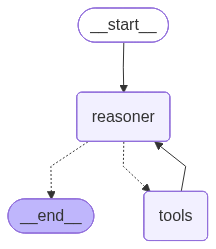

In [24]:
# Display the graph
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [26]:
response = react_graph.invoke({"query": "What is the stock price of Apple add 1000?", "messages": []})
     

KeyboardInterrupt: 

In [ ]:
for m in response['messages']:
    m.pretty_print()